
Loading MRI volume...

Expected Voxels = 7109137
Loaded Voxels = 7109137

MRI Loaded Successfully!

MRI Shape = (181, 217, 181)

Datatype = uint8

Minimum = 0
Maximum = 255

After Normalization:
Minimum = 0.0
Maximum = 1.0


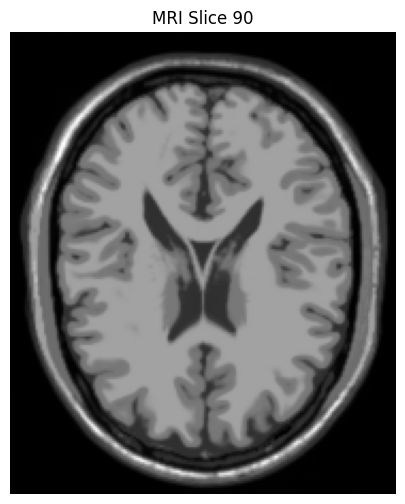


MRI Ready For 3D U-Net!


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FILE PATH
# ============================================================

MRI_PATH = "t1_icbm_normal_1mm_pn0_rf0.rawb"

# ============================================================
# MRI DIMENSIONS
# ============================================================

DEPTH  = 181
HEIGHT = 217
WIDTH  = 181

# ============================================================
# LOAD MRI
# ============================================================

print("\nLoading MRI volume...")

mri_volume = np.fromfile(
    MRI_PATH,
    dtype=np.uint8
)

# ============================================================
# VERIFY SIZE
# ============================================================

expected_voxels = DEPTH * HEIGHT * WIDTH

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", mri_volume.size)

if mri_volume.size != expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {mri_volume.size}"
    )

# ============================================================
# RESHAPE
# ============================================================

mri_volume = mri_volume.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nMRI Loaded Successfully!")

print("\nMRI Shape =", mri_volume.shape)

print("\nDatatype =", mri_volume.dtype)

# ============================================================
# CHECK RANGE
# ============================================================

print("\nMinimum =", np.min(mri_volume))

print("Maximum =", np.max(mri_volume))

# ============================================================
# NORMALIZE
# ============================================================

mri_volume = mri_volume.astype(np.float32)

mri_volume = mri_volume / 255.0

print("\nAfter Normalization:")

print("Minimum =", np.min(mri_volume))

print("Maximum =", np.max(mri_volume))

# ============================================================
# DISPLAY SLICE
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(6,6))

plt.imshow(
    mri_volume[slice_index],
    cmap='gray'
)

plt.title(f"MRI Slice {slice_index}")

plt.axis("off")

plt.show()

print("\nMRI Ready For 3D U-Net!")


Loading Ground Truth Volume...

Expected Voxels = 7109137
Loaded Voxels = 7109137

Ground Truth Loaded Successfully!

Ground Truth Shape = (181, 217, 181)

Datatype = uint8

Unique Labels Found:
[0 1 2 3 4 5 6 7 8 9]


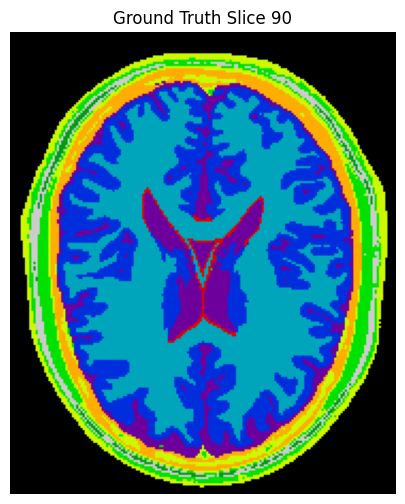


Ground Truth Ready For Training!


In [2]:
#Load Segmentation Label
# ============================================================
# LOAD SEGMENTATION LABEL VOLUME
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# GROUND TRUTH FILE
# ============================================================

GT_PATH = "phantom_1.0mm_normal_crisp.rawb"

# ============================================================
# GROUND TRUTH DIMENSIONS
# ============================================================

DEPTH  = 181
HEIGHT = 217
WIDTH  = 181

# ============================================================
# LOAD GROUND TRUTH
# ============================================================

print("\nLoading Ground Truth Volume...")

gt_volume = np.fromfile(
    GT_PATH,
    dtype=np.uint8
)

# ============================================================
# VERIFY SIZE
# ============================================================

expected_voxels = DEPTH * HEIGHT * WIDTH

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", gt_volume.size)

if gt_volume.size != expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {gt_volume.size}"
    )

# ============================================================
# RESHAPE INTO 3D
# ============================================================

gt_volume = gt_volume.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nGround Truth Loaded Successfully!")

print("\nGround Truth Shape =", gt_volume.shape)

print("\nDatatype =", gt_volume.dtype)

# ============================================================
# CHECK LABEL VALUES
# ============================================================

unique_labels = np.unique(gt_volume)

print("\nUnique Labels Found:")

print(unique_labels)

# ============================================================
# DISPLAY MIDDLE SLICE
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(6,6))

plt.imshow(
    gt_volume[slice_index],
    cmap='nipy_spectral'
)

plt.title(f"Ground Truth Slice {slice_index}")

plt.axis("off")

plt.show()

# ============================================================
# READY
# ============================================================

print("\nGround Truth Ready For Training!")


Loading MRI Volume...

Expected Voxels = 7109137
Loaded Voxels = 7109137

MRI Shape = (181, 217, 181)

Converting To Float32...

Scaling Intensities To [0,1]...

Applying Z-Score Normalization...

Mean = 0.3027944
Std = 0.22435786

Z-Score Normalization Completed!

Final Intensity Statistics
Minimum = -1.3321254
Maximum = 3.1075602
Mean = 1.8634113e-07
Std = 0.99999964


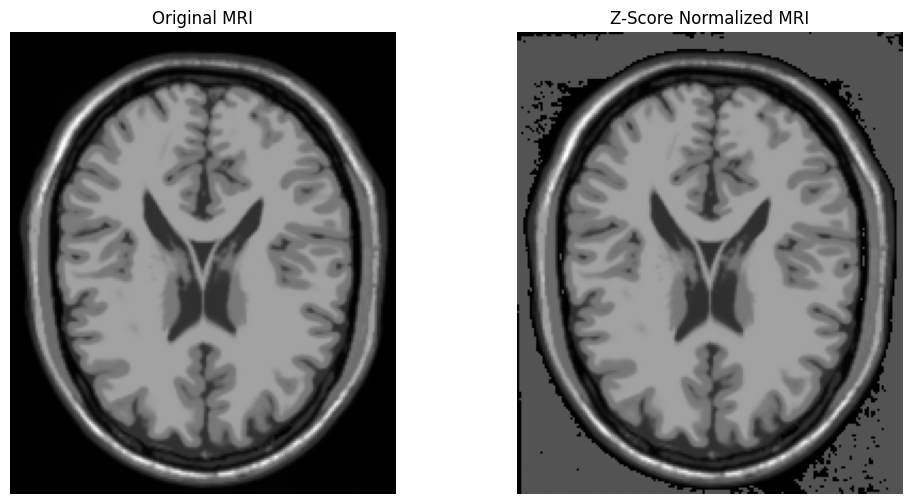


Preprocessing Completed!

Operations Applied:
- Float32 conversion
- Intensity scaling
- Z-score normalization


MRI Ready For 3D U-Net!


In [3]:
# ============================================================
# PREPROCESSING + Z-SCORE NORMALIZATION ONLY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# MRI FILE
# ============================================================

MRI_PATH = "t1_icbm_normal_1mm_pn0_rf0.rawb"

# ============================================================
# MRI DIMENSIONS
# ============================================================

DEPTH  = 181
HEIGHT = 217
WIDTH  = 181

# ============================================================
# LOAD MRI
# ============================================================

print("\nLoading MRI Volume...")

volume = np.fromfile(
    MRI_PATH,
    dtype=np.uint8
)

# ============================================================
# VERIFY SIZE
# ============================================================

expected_voxels = (
    DEPTH *
    HEIGHT *
    WIDTH
)

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", volume.size)

if volume.size != expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {volume.size}"
    )

# ============================================================
# RESHAPE
# ============================================================

volume = volume.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nMRI Shape =", volume.shape)

# ============================================================
# CONVERT TO FLOAT32
# ============================================================

print("\nConverting To Float32...")

volume = volume.astype(np.float32)

# ============================================================
# SCALE TO [0,1]
# ============================================================

print("\nScaling Intensities To [0,1]...")

volume = volume / 255.0

# ============================================================
# Z-SCORE NORMALIZATION ONLY
# ============================================================

print("\nApplying Z-Score Normalization...")

# ------------------------------------------------------------
# USE NON-ZERO VOXELS ONLY
# ------------------------------------------------------------

brain_voxels = volume[
    volume > 0
]

mean = np.mean(
    brain_voxels
)

std = np.std(
    brain_voxels
)

print("\nMean =", mean)

print("Std =", std)

# ------------------------------------------------------------
# Z-SCORE FORMULA
# ------------------------------------------------------------

normalized_volume = (
    volume - mean
) / (
    std + 1e-8
)

# ------------------------------------------------------------
# KEEP BACKGROUND BLACK
# ------------------------------------------------------------

normalized_volume[
    volume == 0
] = 0

print("\nZ-Score Normalization Completed!")

# ============================================================
# CHECK FINAL RANGE
# ============================================================

print("\nFinal Intensity Statistics")

print("Minimum =",
      np.min(normalized_volume))

print("Maximum =",
      np.max(normalized_volume))

print("Mean =",
      np.mean(
          normalized_volume[
              volume > 0
          ]
      ))

print("Std =",
      np.std(
          normalized_volume[
              volume > 0
          ]
      ))

# ============================================================
# VISUALIZATION
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(12,6))

# ------------------------------------------------------------
# ORIGINAL MRI
# ------------------------------------------------------------

plt.subplot(1,2,1)

plt.imshow(
    volume[slice_index],
    cmap='gray'
)

plt.title("Original MRI")

plt.axis("off")

# ------------------------------------------------------------
# NORMALIZED MRI
# ------------------------------------------------------------

plt.subplot(1,2,2)

plt.imshow(
    normalized_volume[slice_index],
    cmap='gray'
)

plt.title("Z-Score Normalized MRI")

plt.axis("off")

plt.show()

# ============================================================
# FINAL INFORMATION
# ============================================================

print("\nPreprocessing Completed!")

print("""
Operations Applied:
- Float32 conversion
- Intensity scaling
- Z-score normalization
""")

print("\nMRI Ready For 3D U-Net!")

In [4]:
# skull s


MRI Shape = (181, 217, 181)
Ground Truth Shape = (181, 217, 181)

Unique Labels After Cleanup
[0 1 2 3]

Extracting 3D Patches...

Total Valid Patches = 1374

Image Patch Shape = (1374, 16, 16, 16, 1)
Mask Patch Shape = (1374, 16, 16, 16)

One Patch Shape = (16, 16, 16, 1)

Patch Intensity Range
Minimum = 0.0
Maximum = 1.0

Unique Labels In Mask Patches
[0 1 2 3]

Selecting Best Brain Patch...
Best Patch Index = 98


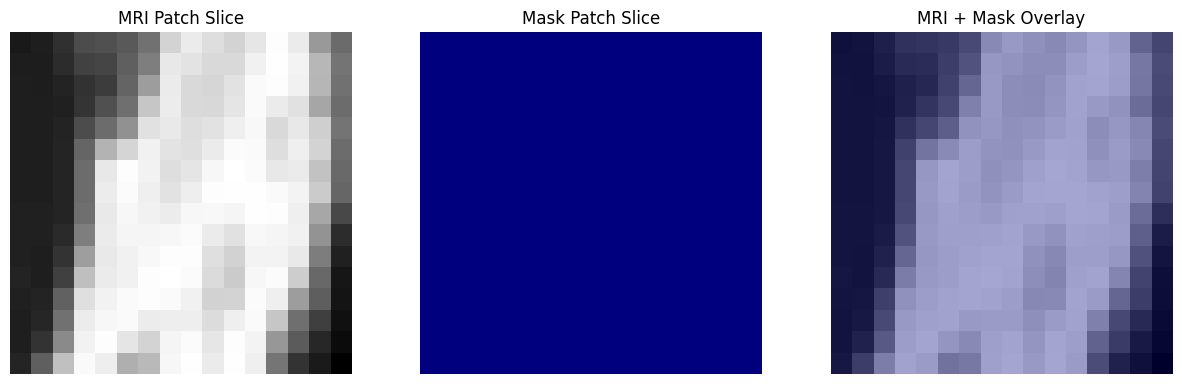


Patch Extraction Completed Successfully!

Ready For 3D U-Net Dataset Creation!

Final Dataset Information
Total Image Patches = 1374
Total Mask Patches = 1374
Patch Size = 16
Stride = 16


In [4]:
#Patch Extraction
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PATCH PARAMETERS
# ============================================================

PATCH_SIZE = 16
STRIDE = 16

print("\nMRI Shape =", volume.shape)

print("Ground Truth Shape =", gt_volume.shape)

# ============================================================
# KEEP ONLY 3 CLASSES
# ============================================================

gt_volume[gt_volume > 3] = 0

print("\nUnique Labels After Cleanup")

print(np.unique(gt_volume))

# ============================================================
# PATCH STORAGE
# ============================================================

image_patches = []

mask_patches = []

DEPTH, HEIGHT, WIDTH = volume.shape

print("\nExtracting 3D Patches...")

patch_count = 0

# ============================================================
# PATCH EXTRACTION
# ============================================================

for z in range(
    0,
    DEPTH - PATCH_SIZE + 1,
    STRIDE
):

    for y in range(
        0,
        HEIGHT - PATCH_SIZE + 1,
        STRIDE
    ):

        for x in range(
            0,
            WIDTH - PATCH_SIZE + 1,
            STRIDE
        ):

            image_patch = volume[
                z:z+PATCH_SIZE,
                y:y+PATCH_SIZE,
                x:x+PATCH_SIZE
            ]

            mask_patch = gt_volume[
                z:z+PATCH_SIZE,
                y:y+PATCH_SIZE,
                x:x+PATCH_SIZE
            ]

            # ------------------------------------------------
            # REMOVE EMPTY PATCHES
            # ------------------------------------------------

            if np.sum(image_patch) > 5:

                image_patches.append(
                    image_patch
                )

                mask_patches.append(
                    mask_patch
                )

                patch_count += 1

# ============================================================
# CONVERT TO NUMPY ARRAYS
# ============================================================

print("\nTotal Valid Patches =",
      patch_count)

image_patches = np.array(
    image_patches,
    dtype=np.float32
)

mask_patches = np.array(
    mask_patches,
    dtype=np.uint8
)

# ============================================================
# ADD CHANNEL DIMENSION
# ============================================================

image_patches = np.expand_dims(
    image_patches,
    axis=-1
)

# ============================================================
# PATCH INFORMATION
# ============================================================

print("\nImage Patch Shape =",
      image_patches.shape)

print("Mask Patch Shape =",
      mask_patches.shape)

print("\nOne Patch Shape =",
      image_patches[0].shape)

print("\nPatch Intensity Range")

print("Minimum =",
      np.min(image_patches))

print("Maximum =",
      np.max(image_patches))

print("\nUnique Labels In Mask Patches")

print(np.unique(mask_patches))

# ============================================================
# FIND BEST PATCH
# ============================================================

print("\nSelecting Best Brain Patch...")

best_patch_index = 0

max_intensity = 0

for i in range(len(image_patches)):

    patch_sum = np.sum(
        image_patches[i]
    )

    if patch_sum > max_intensity:

        max_intensity = patch_sum

        best_patch_index = i

print("Best Patch Index =",
      best_patch_index)

# ============================================================
# VISUALIZATION
# ============================================================

sample_patch = image_patches[
    best_patch_index
]

sample_mask = mask_patches[
    best_patch_index
]

middle_slice = PATCH_SIZE // 2

plt.figure(figsize=(15,5))

# ---------------- MRI PATCH ----------------

plt.subplot(1,3,1)

plt.imshow(
    sample_patch[middle_slice,:,:,0],
    cmap='gray'
)

plt.title("MRI Patch Slice")

plt.axis("off")

# ---------------- MASK PATCH ----------------

plt.subplot(1,3,2)

plt.imshow(
    sample_mask[middle_slice],
    cmap='jet'
)

plt.title("Mask Patch Slice")

plt.axis("off")

# ---------------- OVERLAY ----------------

plt.subplot(1,3,3)

plt.imshow(
    sample_patch[middle_slice,:,:,0],
    cmap='gray'
)

plt.imshow(
    sample_mask[middle_slice],
    cmap='jet',
    alpha=0.35
)

plt.title("MRI + Mask Overlay")

plt.axis("off")

plt.show()

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\nPatch Extraction Completed Successfully!")

print("\nReady For 3D U-Net Dataset Creation!")

print("\nFinal Dataset Information")

print("Total Image Patches =",
      len(image_patches))

print("Total Mask Patches =",
      len(mask_patches))

print("Patch Size =",
      PATCH_SIZE)

print("Stride =",
      STRIDE)

In [7]:
# ============================================================
# CONVERT 16x16x16 PATCHES TO PYTORCH TENSORS
# PATCH SIZE = 16
# STRIDE = 16
# ============================================================

import torch
import numpy as np

print("\nConverting 16x16x16 Patches To PyTorch Tensors...")

# ============================================================
# PATCH CONFIGURATION
# ============================================================

PATCH_SIZE = 16
STRIDE = 16

print("\nPatch Size =", PATCH_SIZE)

print("Stride =", STRIDE)

print("Overlap =", PATCH_SIZE - STRIDE)

# ============================================================
# VERIFY INPUT TYPES
# ============================================================

print("\nInput Verification")

print("Image Patches Type =",
      type(image_patches))

print("Mask Patches Type =",
      type(mask_patches))

# ============================================================
# NUMPY -> TORCH
# ============================================================

print("\nConverting NumPy Arrays To Tensors...")

if isinstance(image_patches, np.ndarray):

    image_patches = torch.from_numpy(
        image_patches
    ).float()

if isinstance(mask_patches, np.ndarray):

    mask_patches = torch.from_numpy(
        mask_patches
    ).long()

# ============================================================
# CURRENT SHAPES
# ============================================================

print("\nCurrent Tensor Shapes")

print("Image Tensor Shape =",
      image_patches.shape)

print("Mask Tensor Shape =",
      mask_patches.shape)

# ============================================================
# CHECK TENSOR FORMAT
#
# WRONG FORMAT:
# [B, D, H, W, C]
#
# CORRECT FORMAT:
# [B, C, D, H, W]
# ============================================================

print("\nChecking Tensor Format...")

if len(image_patches.shape) == 5:

    # --------------------------------------------------------
    # CHANNEL IS LAST
    # --------------------------------------------------------

    if image_patches.shape[-1] == 1:

        print("\nChannel Found At Last Dimension")

        print("Reordering Tensor Dimensions...")

        image_patches = image_patches.permute(
            0, 4, 1, 2, 3
        )

    # --------------------------------------------------------
    # ALREADY CORRECT
    # --------------------------------------------------------

    elif image_patches.shape[1] == 1:

        print("\nTensor Already In Correct Format")

    # --------------------------------------------------------
    # PREVIOUSLY WRONG PERMUTATION
    # --------------------------------------------------------

    elif image_patches.shape[2] == 1:

        print("\nFixing Incorrect Tensor Order...")

        image_patches = image_patches.permute(
            0, 2, 1, 3, 4
        )

# ============================================================
# CONTIGUOUS MEMORY
# ============================================================

image_patches = image_patches.contiguous()

mask_patches = mask_patches.contiguous()

# ============================================================
# FINAL SHAPES
# ============================================================

print("\nFinal Tensor Shapes")

print("Image Tensor Shape =",
      image_patches.shape)

print("Mask Tensor Shape =",
      mask_patches.shape)

# ============================================================
# DIMENSION MEANING
# ============================================================

print("\nTensor Dimension Meaning")

print("[Batch, Channel, Depth, Height, Width]")

# ============================================================
# DIMENSION DETAILS
# ============================================================

BATCH_SIZE = image_patches.shape[0]

CHANNELS = image_patches.shape[1]

DEPTH = image_patches.shape[2]

HEIGHT = image_patches.shape[3]

WIDTH = image_patches.shape[4]

print("\nDimension Interpretation")

print("Total Patches =",
      BATCH_SIZE)

print("Channels =",
      CHANNELS)

print("Depth =",
      DEPTH)

print("Height =",
      HEIGHT)

print("Width =",
      WIDTH)

# ============================================================
# VERIFY PATCH SIZE
# ============================================================

print("\nPatch Size Verification")

if (
    CHANNELS == 1 and
    DEPTH == PATCH_SIZE and
    HEIGHT == PATCH_SIZE and
    WIDTH == PATCH_SIZE
):

    print("Tensor Format Correct")

else:

    print("Tensor Format Incorrect")

# ============================================================
# VERIFY LABELS
# ============================================================

print("\nUnique Labels In Mask Tensor")

print(torch.unique(mask_patches))

# ============================================================
# VERIFY DATA TYPES
# ============================================================

print("\nTensor Data Types")

print("Image Tensor Dtype =",
      image_patches.dtype)

print("Mask Tensor Dtype =",
      mask_patches.dtype)

# ============================================================
# SAMPLE PATCH
# ============================================================

print("\nSample Patch Information")

sample_image = image_patches[0]

sample_mask = mask_patches[0]

print("One Image Patch Shape =",
      sample_image.shape)

print("One Mask Patch Shape =",
      sample_mask.shape)

# ============================================================
# VALUE RANGE
# ============================================================

print("\nImage Tensor Intensity Range")

print("Minimum =",
      torch.min(image_patches).item())

print("Maximum =",
      torch.max(image_patches).item())

# ============================================================
# MEMORY USAGE
# ============================================================

image_memory = (
    image_patches.element_size()
    * image_patches.nelement()
) / (1024**2)

mask_memory = (
    mask_patches.element_size()
    * mask_patches.nelement()
) / (1024**2)

print("\nApproximate Memory Usage")

print("Image Tensor Memory =",
      round(image_memory, 2),
      "MB")

print("Mask Tensor Memory =",
      round(mask_memory, 2),
      "MB")

# ============================================================
# FINAL STATUS
# ============================================================

print("\nTensor Preparation Completed Successfully!")

print("\nDataset Ready For:")

print("- Lightweight 3D U-Net")

print("- 16x16x16 Patch Training")

print("- Batch-wise Processing")

print("- Brain MRI Segmentation")

print("- WM / GM / CSF Prediction")



Converting 16x16x16 Patches To PyTorch Tensors...

Patch Size = 16
Stride = 16
Overlap = 0

Input Verification
Image Patches Type = <class 'numpy.ndarray'>
Mask Patches Type = <class 'numpy.ndarray'>

Converting NumPy Arrays To Tensors...

Current Tensor Shapes
Image Tensor Shape = torch.Size([1374, 16, 16, 16, 1])
Mask Tensor Shape = torch.Size([1374, 16, 16, 16])

Checking Tensor Format...

Channel Found At Last Dimension
Reordering Tensor Dimensions...

Final Tensor Shapes
Image Tensor Shape = torch.Size([1374, 1, 16, 16, 16])
Mask Tensor Shape = torch.Size([1374, 16, 16, 16])

Tensor Dimension Meaning
[Batch, Channel, Depth, Height, Width]

Dimension Interpretation
Total Patches = 1374
Channels = 1
Depth = 16
Height = 16
Width = 16

Patch Size Verification
Tensor Format Correct

Unique Labels In Mask Tensor
tensor([0, 1, 2, 3])

Tensor Data Types
Image Tensor Dtype = torch.float32
Mask Tensor Dtype = torch.int64

Sample Patch Information
One Image Patch Shape = torch.Size([1, 16, 

In [8]:
# ============================================================
# LIGHTWEIGHT 3D U-NET
# FOR PATCH SIZE = 16
# STRIDE = 16
# ============================================================

import torch
import torch.nn as nn

print("\nCreating Lightweight 3D U-Net...")

# ============================================================
# DOUBLE CONVOLUTION BLOCK
# ============================================================

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            # ------------------------------------------------
            # CONVOLUTION 1
            # ------------------------------------------------

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            # ------------------------------------------------
            # CONVOLUTION 2
            # ------------------------------------------------

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

# ============================================================
# LIGHTWEIGHT 3D U-NET
# ============================================================

class UNet3D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=4
    ):

        super(UNet3D, self).__init__()

        print("\nBuilding Encoder Path...")

        # ====================================================
        # ENCODER LEVEL 1
        # ====================================================

        self.enc1 = DoubleConv(
            in_channels,
            16
        )

        self.pool1 = nn.MaxPool3d(
            kernel_size=2,
            stride=2
        )

        # ====================================================
        # ENCODER LEVEL 2
        # ====================================================

        self.enc2 = DoubleConv(
            16,
            32
        )

        self.pool2 = nn.MaxPool3d(
            kernel_size=2,
            stride=2
        )

        # ====================================================
        # BOTTLENECK
        # ====================================================

        print("\nBuilding Bottleneck...")

        self.bottleneck = DoubleConv(
            32,
            64
        )

        # ====================================================
        # DECODER LEVEL 2
        # ====================================================

        print("\nBuilding Decoder Path...")

        self.up2 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            64,
            32
        )

        # ====================================================
        # DECODER LEVEL 1
        # ====================================================

        self.up1 = nn.ConvTranspose3d(
            32,
            16,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            32,
            16
        )

        # ====================================================
        # FINAL OUTPUT LAYER
        # ====================================================

        print("\nCreating Final Output Layer...")

        self.final = nn.Conv3d(
            16,
            out_channels,
            kernel_size=1
        )

    # ========================================================
    # FORWARD PASS
    # ========================================================

    def forward(self, x):

        # ====================================================
        # ENCODER LEVEL 1
        # ====================================================

        e1 = self.enc1(x)

        p1 = self.pool1(e1)

        # ====================================================
        # ENCODER LEVEL 2
        # ====================================================

        e2 = self.enc2(p1)

        p2 = self.pool2(e2)

        # ====================================================
        # BOTTLENECK
        # ====================================================

        b = self.bottleneck(p2)

        # ====================================================
        # DECODER LEVEL 2
        # ====================================================

        u2 = self.up2(b)

        u2 = torch.cat(
            [u2, e2],
            dim=1
        )

        d2 = self.dec2(u2)

        # ====================================================
        # DECODER LEVEL 1
        # ====================================================

        u1 = self.up1(d2)

        u1 = torch.cat(
            [u1, e1],
            dim=1
        )

        d1 = self.dec1(u1)

        # ====================================================
        # FINAL OUTPUT
        # ====================================================

        out = self.final(d1)

        return out

# ============================================================
# INITIALIZE MODEL
# ============================================================

print("\nInitializing Lightweight 3D U-Net...")

model = UNet3D(
    in_channels=1,
    out_channels=4
)

print("\n3D U-Net Created Successfully!")

# ============================================================
# TEST FORWARD PASS
# ============================================================

print("\nTesting Forward Pass...")

sample_input = torch.randn(
    2,
    1,
    16,
    16,
    16
)

output = model(sample_input)

print("\nForward Pass Completed!")

# ============================================================
# OUTPUT INFORMATION
# ============================================================

print("\nFinal Prediction Shape =",
      output.shape)

print("\nTensor Meaning")

print("[Batch, Classes, Depth, Height, Width]")

print("\nExplanation")

print("Batch Size =",
      output.shape[0])

print("Classes =",
      output.shape[1])

print("Depth =",
      output.shape[2])

print("Height =",
      output.shape[3])

print("Width =",
      output.shape[4])

print("\nLightweight 3D U-Net Ready For Training!")


Creating Lightweight 3D U-Net...

Initializing Lightweight 3D U-Net...

Building Encoder Path...

Building Bottleneck...

Building Decoder Path...

Creating Final Output Layer...

3D U-Net Created Successfully!

Testing Forward Pass...

Forward Pass Completed!

Final Prediction Shape = torch.Size([2, 4, 16, 16, 16])

Tensor Meaning
[Batch, Classes, Depth, Height, Width]

Explanation
Batch Size = 2
Classes = 4
Depth = 16
Height = 16
Width = 16

Lightweight 3D U-Net Ready For Training!


In [ ]:
# ============================================================
# SOFTMAX PROBABILITY FOR 16x16x16 PATCHES
# PATCH SIZE = 16
# STRIDE = 16
# ============================================================

import torch
import torch.nn as nn

print("\nCreating Example Network Output...")

# ============================================================
# PARAMETERS
# ============================================================

BATCH_SIZE = 2

NUM_CLASSES = 4

DEPTH  = 16
HEIGHT = 16
WIDTH  = 16

# ============================================================
# SIMULATED NETWORK OUTPUT
# ============================================================

output = torch.randn(
    BATCH_SIZE,
    NUM_CLASSES,
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nRaw Network Output Shape =",
      output.shape)

# ============================================================
# OUTPUT MEANING
# ============================================================

print("\nTensor Meaning")

print("""
[Batch, Classes, Depth, Height, Width]
""")

print("\nEach voxel contains raw class scores.")

# ============================================================
# EXAMPLE VOXEL SCORES
# ============================================================

print("\nExample Raw Scores For One Voxel")

center_voxel = PATCH_SIZE = 16 // 2

voxel_scores = output[
    0,
    :,
    center_voxel,
    center_voxel,
    center_voxel
]

print(voxel_scores)

# ============================================================
# SOFTMAX PROBABILITIES
# ============================================================

print("\nApplying Softmax Probability...")

probabilities = torch.softmax(
    output,
    dim=1
)

print("\nProbability Tensor Shape =",
      probabilities.shape)

# ============================================================
# EXAMPLE VOXEL PROBABILITIES
# ============================================================

print("\nExample Voxel Probabilities")

voxel_probabilities = probabilities[
    0,
    :,
    center_voxel,
    center_voxel,
    center_voxel
]

print(voxel_probabilities)

# ============================================================
# VERIFY PROBABILITY SUM
# ============================================================

print("\nProbability Sum")

print(torch.sum(voxel_probabilities))

# ============================================================
# CLASS LABELS
# ============================================================

print("\nClass Labels")

print("""
0 → Background
1 → CSF
2 → Gray Matter (GM)
3 → White Matter (WM)
""")

# ============================================================
# PROBABILITY INTERPRETATION
# ============================================================

print("\nVoxel-wise Probability Interpretation")

print(f"Background Probability = "
      f"{voxel_probabilities[0]:.4f}")

print(f"CSF Probability = "
      f"{voxel_probabilities[1]:.4f}")

print(f"GM Probability = "
      f"{voxel_probabilities[2]:.4f}")

print(f"WM Probability = "
      f"{voxel_probabilities[3]:.4f}")

# ============================================================
# FINAL PREDICTION
# ============================================================

print("\nFinding Final Predicted Class...")

predicted_class = torch.argmax(
    voxel_probabilities
)

print("Predicted Class =",
      predicted_class.item())

# ============================================================
# CLASS INTERPRETATION
# ============================================================

class_names = {
    0: "Background",
    1: "CSF",
    2: "Gray Matter",
    3: "White Matter"
}

print("\nPrediction Meaning")

print("Prediction =",
      class_names[predicted_class.item()])

# ============================================================
# FULL PATCH PREDICTION
# ============================================================

print("\nGenerating Full Segmentation Patch...")

predicted_patch = torch.argmax(
    probabilities,
    dim=1
)

print("\nPredicted Patch Shape =",
      predicted_patch.shape)

# ============================================================
# OUTPUT SHAPE EXPLANATION
# ============================================================

print("\nPredicted Patch Meaning")

print("""
[Batch, Depth, Height, Width]
""")

print("\nEach voxel now contains:")

print("""
0 → Background
1 → CSF
2 → GM
3 → WM
""")

# ============================================================
# UNIQUE LABELS
# ============================================================

print("\nUnique Predicted Labels")

print(torch.unique(predicted_patch))

# ============================================================
# WHY SOFTMAX
# ============================================================

print("\nWhy Softmax Is Important")

print("""
Softmax converts raw network scores
into probabilities between 0 and 1.

The probabilities indicate how confident
the network is for each tissue class.
""")

# ============================================================
# EXAMPLE INTERPRETATION
# ============================================================

print("\nExample")

print("""
Background = 0.01
CSF        = 0.80
GM         = 0.15
WM         = 0.04

Prediction = CSF
""")

# ============================================================
# IMPORTANT TRAINING NOTE
# ============================================================

print("\nIMPORTANT")

print("""
During training:

DO NOT manually apply softmax
before CrossEntropyLoss.

Use:

loss = criterion(output, target)

CrossEntropyLoss internally applies
LogSoftmax automatically.
""")

# ============================================================
# FINAL STATUS
# ============================================================

print("\nSoftmax Probability Stage Completed!")

print("\nReady For:")

print("- Voxel-wise Classification")

print("- 3D Segmentation Prediction")

print("- Patch Reconstruction")

print("- Brain Tissue Segmentation")

print("- WM / GM / CSF Prediction")


Creating Example Network Output...

Raw Network Output Shape = torch.Size([2, 4, 32, 32, 32])

Tensor Meaning

[Batch, Classes, Depth, Height, Width]


Each voxel contains raw class scores.

Example Raw Scores For One Voxel
tensor([-0.5713,  0.3357,  1.7703,  0.1416])

Applying Softmax Probability...

Probability Tensor Shape = torch.Size([2, 4, 32, 32, 32])

Example Voxel Probabilities
tensor([0.0628, 0.1556, 0.6534, 0.1282])

Probability Sum
tensor(1.0000)

Class Labels

0 → Background
1 → CSF
2 → Gray Matter (GM)
3 → White Matter (WM)


Voxel-wise Probability Interpretation
Background Probability = 0.0628
CSF Probability = 0.1556
GM Probability = 0.6534
WM Probability = 0.1282

Finding Final Predicted Class...
Predicted Class = 2

Prediction Meaning
Prediction = Gray Matter

Why Softmax Is Important

Softmax converts raw network scores
into probabilities between 0 and 1.

The probabilities indicate how confident
the network is for each tissue class.


Example

Background = 0.01
CSF

In [9]:
#Loss Function
# @title
import torch
import torch.nn as nn
import torch.nn.functional as F

print("\nCreating Example Prediction Tensor...")

# ============================================================
# PARAMETERS
# ============================================================

BATCH_SIZE = 2

NUM_CLASSES = 4

DEPTH  = 32
HEIGHT = 32
WIDTH  = 32

# ============================================================
# SIMULATED NETWORK OUTPUT
# ============================================================

predictions = torch.randn(
    BATCH_SIZE,
    NUM_CLASSES,
    DEPTH,
    HEIGHT,
    WIDTH,
    requires_grad=True
)

print("\nPrediction Tensor Shape =",
      predictions.shape)

print("\nTensor Meaning")

print("""
[Batch, Classes, Depth, Height, Width]
""")

# ============================================================
# GROUND TRUTH
# ============================================================

print("\nCreating Ground Truth Labels...")

ground_truth = torch.randint(
    0,
    NUM_CLASSES,
    (
        BATCH_SIZE,
        DEPTH,
        HEIGHT,
        WIDTH
    )
)

print("\nGround Truth Shape =",
      ground_truth.shape)

print("\nGround Truth Meaning")

print("""
[Batch, Depth, Height, Width]

Each voxel contains an integer label:

0 = Background
1 = CSF
2 = Gray Matter
3 = White Matter
""")

# ============================================================
# SOFTMAX
# ============================================================

print("\nApplying Softmax...")

probabilities = F.softmax(
    predictions,
    dim=1
)

print("\nProbability Tensor Shape =",
      probabilities.shape)

# ============================================================
# DICE LOSS
# ============================================================

class DiceLoss(nn.Module):

    def __init__(
        self,
        smooth=1e-5
    ):

        super(DiceLoss, self).__init__()

        self.smooth = smooth

    def forward(
        self,
        predictions,
        targets
    ):

        print("\nInside Dice Loss")

        # ----------------------------------------------------
        # ONE-HOT ENCODING
        # ----------------------------------------------------

        print("\nConverting Ground Truth To One-Hot Encoding...")

        targets_one_hot = F.one_hot(
            targets,
            NUM_CLASSES
        )

        print("One-Hot Shape =",
              targets_one_hot.shape)

        # ----------------------------------------------------
        # PERMUTE
        # ----------------------------------------------------

        targets_one_hot = targets_one_hot.permute(
            0,
            4,
            1,
            2,
            3
        ).float()

        print("\nPermuted One-Hot Shape =",
              targets_one_hot.shape)

        # ----------------------------------------------------
        # FLATTEN
        # ----------------------------------------------------

        print("\nFlattening Tensors...")

        predictions = predictions.contiguous().view(
            predictions.shape[0],
            predictions.shape[1],
            -1
        )

        targets_one_hot = targets_one_hot.contiguous().view(
            targets_one_hot.shape[0],
            targets_one_hot.shape[1],
            -1
        )

        print("Predictions Shape =",
              predictions.shape)

        print("Targets Shape =",
              targets_one_hot.shape)

        # ----------------------------------------------------
        # INTERSECTION
        # ----------------------------------------------------

        print("\nComputing Intersection...")

        intersection = (
            predictions *
            targets_one_hot
        ).sum(dim=2)

        print("Intersection Shape =",
              intersection.shape)

        # ----------------------------------------------------
        # UNION
        # ----------------------------------------------------

        print("\nComputing Union...")

        union = (
            predictions.sum(dim=2)
            +
            targets_one_hot.sum(dim=2)
        )

        print("Union Shape =",
              union.shape)

        # ----------------------------------------------------
        # DICE FORMULA
        # ----------------------------------------------------

        print("\nDice Formula")

        print("""
Dice =
(2 × Intersection)
/
(Prediction + GroundTruth)
""")

        dice_score = (
            2.0 * intersection + self.smooth
        ) / (
            union + self.smooth
        )

        print("\nDice Score Shape =",
              dice_score.shape)

        print("\nMean Dice Score =",
              dice_score.mean().item())

        # ----------------------------------------------------
        # FINAL LOSS
        # ----------------------------------------------------

        dice_loss = 1 - dice_score.mean()

        return dice_loss

# ============================================================
# INITIALIZE DICE LOSS
# ============================================================

print("\nInitializing Dice Loss...")

dice_loss_function = DiceLoss()

# ============================================================
# COMPUTE DICE LOSS
# ============================================================

print("\nComputing Dice Loss...")

dice_loss = dice_loss_function(
    probabilities,
    ground_truth
)

print("\nDice Loss Value =",
      dice_loss.item())

# ============================================================
# CROSS ENTROPY LOSS
# ============================================================

print("\nCreating CrossEntropy Loss...")

cross_entropy_loss_function = nn.CrossEntropyLoss()

cross_entropy_loss = cross_entropy_loss_function(
    predictions,
    ground_truth
)

print("\nCrossEntropy Loss Value =",
      cross_entropy_loss.item())

# ============================================================
# COMBINED LOSS
# ============================================================

print("\nCombining Losses...")

combined_loss = (
    dice_loss +
    cross_entropy_loss
)

print("\nCombined Loss Value =",
      combined_loss.item())

# ============================================================
# WHY DICE LOSS
# ============================================================

print("\nWhy Dice Loss Is Important")

print("""
Dice Loss measures overlap between:

1. Predicted segmentation

2. Ground truth segmentation

It is very important for medical imaging
because segmentation datasets often have:

- class imbalance
- small structures
- sparse regions
""")

# ============================================================
# WHY CROSS ENTROPY
# ============================================================

print("\nWhy CrossEntropy Helps")

print("""
CrossEntropy improves:

- voxel classification
- class separation
- probability learning
""")

# ============================================================
# WHY COMBINED LOSS
# ============================================================

print("\nWhy Combined Loss Works Best")

print("""
Dice Loss:
improves overlap quality

CrossEntropy:
improves classification stability

Together:
better segmentation performance
""")

# ============================================================
# FINAL FORMULA
# ============================================================

print("\nFinal Combined Loss")

print("""
Loss = DiceLoss + CrossEntropyLoss
""")

# ============================================================
# IMPORTANT NOTE
# ============================================================

print("\nIMPORTANT")

print("""
Dice Loss uses probabilities
(after softmax).

CrossEntropyLoss uses raw logits
(before softmax).
""")

# ============================================================
# READY
# ============================================================

print("\nLoss Function Ready For Training!")


Creating Example Prediction Tensor...

Prediction Tensor Shape = torch.Size([2, 4, 32, 32, 32])

Tensor Meaning

[Batch, Classes, Depth, Height, Width]


Creating Ground Truth Labels...

Ground Truth Shape = torch.Size([2, 32, 32, 32])

Ground Truth Meaning

[Batch, Depth, Height, Width]

Each voxel contains an integer label:

0 = Background
1 = CSF
2 = Gray Matter
3 = White Matter


Applying Softmax...

Probability Tensor Shape = torch.Size([2, 4, 32, 32, 32])

Initializing Dice Loss...

Computing Dice Loss...

Inside Dice Loss

Converting Ground Truth To One-Hot Encoding...
One-Hot Shape = torch.Size([2, 32, 32, 32, 4])

Permuted One-Hot Shape = torch.Size([2, 4, 32, 32, 32])

Flattening Tensors...
Predictions Shape = torch.Size([2, 4, 32768])
Targets Shape = torch.Size([2, 4, 32768])

Computing Intersection...
Intersection Shape = torch.Size([2, 4])

Computing Union...
Union Shape = torch.Size([2, 4])

Dice Formula

Dice =
(2 × Intersection)
/
(Prediction + GroundTruth)


Dice Scor

In [10]:
# ============================================================
# BACKPROPAGATION
# FOR 16x16x16 PATCHES
# STRIDE = 16
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

print("\nInitializing Lightweight 3D U-Net...")

# ============================================================
# INITIALIZE MODEL
# ============================================================

model = UNet3D(
    in_channels=1,
    out_channels=4
)

# ============================================================
# DEVICE CONFIGURATION
# ============================================================

print("\nMoving Model To Device...")

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device =", DEVICE)

model = model.to(DEVICE)

# ============================================================
# OPTIMIZER
# ============================================================

print("\nCreating Optimizer...")

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("\nOptimizer Created Successfully!")

# ============================================================
# WHY ADAM
# ============================================================

print("\nWhy Adam Optimizer?")

print("""
Adam is widely used in deep learning because:

1. Fast convergence

2. Adaptive learning rate

3. Stable optimization

4. Works well for medical imaging

5. Handles complex 3D CNN training
""")

# ============================================================
# LEARNING RATE
# ============================================================

print("\nLearning Rate")

print("""
lr = 1e-4

Small learning rate helps:

- stable training
- smooth convergence
- better segmentation learning
""")

# ============================================================
# EXAMPLE INPUT BATCH
# ============================================================

print("\nCreating Example Input Batch...")

images = torch.randn(
    2,
    1,
    16,
    16,
    16
).to(DEVICE)

print("Image Batch Shape =",
      images.shape)

# ============================================================
# EXAMPLE GROUND TRUTH
# ============================================================

print("\nCreating Example Ground Truth...")

masks = torch.randint(
    0,
    4,
    (
        2,
        16,
        16,
        16
    )
).to(DEVICE)

print("Mask Shape =",
      masks.shape)

# ============================================================
# MASK MEANING
# ============================================================

print("\nMask Meaning")

print("""
Each voxel contains:

0 = Background
1 = CSF
2 = Gray Matter
3 = White Matter
""")

# ============================================================
# FORWARD PROPAGATION
# ============================================================

print("\nForward Propagation...")

outputs = model(images)

print("\nOutput Shape =",
      outputs.shape)

# ============================================================
# OUTPUT MEANING
# ============================================================

print("\nOutput Tensor Meaning")

print("""
[Batch, Classes, Depth, Height, Width]
""")

# ============================================================
# CROSS ENTROPY LOSS
# ============================================================

print("\nComputing CrossEntropy Loss...")

criterion = nn.CrossEntropyLoss()

loss = criterion(
    outputs,
    masks
)

print("\nLoss Value =",
      loss.item())

# ============================================================
# BACKPROPAGATION WORKFLOW
# ============================================================

print("\nBackpropagation Workflow")

print("""
1. Forward Pass
2. Compute Loss
3. Compute Gradients
4. Update Weights
""")

# ============================================================
# ZERO PREVIOUS GRADIENTS
# ============================================================

print("\nStep 1 — Zero Previous Gradients")

optimizer.zero_grad()

print("Previous gradients cleared.")

# ============================================================
# BACKWARD PROPAGATION
# ============================================================

print("\nStep 2 — Backward Propagation")

loss.backward()

print("Gradients Computed Successfully!")

# ============================================================
# WHAT BACKPROP DOES
# ============================================================

print("\nWhat Backpropagation Computes")

print("""
Backpropagation calculates:

∂Loss / ∂Weights

for every trainable parameter
inside the 3D U-Net.
""")

# ============================================================
# UPDATE NETWORK WEIGHTS
# ============================================================

print("\nStep 3 — Updating Weights")

optimizer.step()

print("Weights Updated Successfully!")

# ============================================================
# WEIGHT UPDATE MEANING
# ============================================================

print("\nMeaning Of Weight Update")

print("""
The optimizer modifies network weights
to reduce segmentation error.

After many iterations:

- Dice score improves
- tissue prediction improves
- segmentation becomes accurate
""")

# ============================================================
# VERIFY OUTPUT SHAPE
# ============================================================

print("\nVerifying Output Dimensions")

print("Input Shape  =",
      images.shape)

print("Output Shape =",
      outputs.shape)

print("Mask Shape   =",
      masks.shape)

# ============================================================
# IMPORTANT TRAINING NOTE
# ============================================================

print("\nIMPORTANT")

print("""
For 16x16x16 patches:

Input shape:
[B, 1, 16, 16, 16]

Target shape:
[B, 16, 16, 16]

Output shape:
[B, 4, 16, 16, 16]
""")

# ============================================================
# FINAL STATUS
# ============================================================

print("\nTraining Iteration Completed Successfully!")

print("\n3D U-Net Ready For Full Training Loop!")

print("\nReady For:")

print("- Epoch Training")

print("- Dice Score Computation")

print("- Validation Loop")

print("- Patch Prediction")

print("- Brain MRI Segmentation")

print("- WM / GM / CSF Segmentation")


Initializing Lightweight 3D U-Net...

Building Encoder Path...

Building Bottleneck...

Building Decoder Path...

Creating Final Output Layer...

Moving Model To Device...
Device = cpu

Creating Optimizer...

Optimizer Created Successfully!

Why Adam Optimizer?

Adam is widely used in deep learning because:

1. Fast convergence

2. Adaptive learning rate

3. Stable optimization

4. Works well for medical imaging

5. Handles complex 3D CNN training


Learning Rate

lr = 1e-4

Small learning rate helps:

- stable training
- smooth convergence
- better segmentation learning


Creating Example Input Batch...
Image Batch Shape = torch.Size([2, 1, 16, 16, 16])

Creating Example Ground Truth...
Mask Shape = torch.Size([2, 16, 16, 16])

Mask Meaning

Each voxel contains:

0 = Background
1 = CSF
2 = Gray Matter
3 = White Matter


Forward Propagation...

Output Shape = torch.Size([2, 4, 16, 16, 16])

Output Tensor Meaning

[Batch, Classes, Depth, Height, Width]


Computing CrossEntropy Loss...



Device = cpu

Initializing Lightweight 3D U-Net...

Building Encoder Path...

Building Bottleneck...

Building Decoder Path...

Creating Final Output Layer...

Creating Dataset...
Total Batches = 344

Training Configuration
Patch Size = 16
Stride = 16
Batch Size = 4
Epochs = 30

Starting Training...

Epoch 1/30
Batch 1 Loss = 1.5137
Batch 2 Loss = 1.4588
Batch 3 Loss = 1.4354
Batch 4 Loss = 1.4682
Batch 5 Loss = 1.4382
Batch 6 Loss = 1.4784
Batch 7 Loss = 1.4726
Batch 8 Loss = 1.4782
Batch 9 Loss = 1.2078
Batch 10 Loss = 1.4714
Batch 11 Loss = 1.3648
Batch 12 Loss = 1.2689
Batch 13 Loss = 1.4621
Batch 14 Loss = 1.2269
Batch 15 Loss = 1.2880
Batch 16 Loss = 1.2768
Batch 17 Loss = 1.3002
Batch 18 Loss = 1.5908
Batch 19 Loss = 1.4874
Batch 20 Loss = 1.1785
Batch 21 Loss = 1.2890
Batch 22 Loss = 1.4608
Batch 23 Loss = 1.0043
Batch 24 Loss = 1.1399
Batch 25 Loss = 1.3077
Batch 26 Loss = 1.1233
Batch 27 Loss = 1.2867
Batch 28 Loss = 1.0852
Batch 29 Loss = 0.9997
Batch 30 Loss = 1.4641
Batch

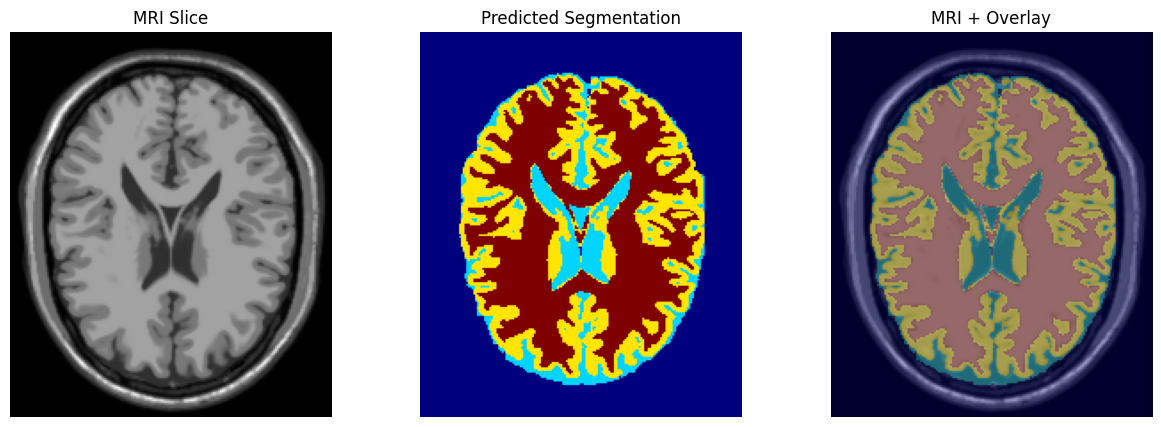


Saving Segmentation...
Segmentation Saved Successfully!

3D Brain Segmentation Completed Successfully!

Workflow

MRI Volume
↓
Extract 16³ Patch
↓
Predict Tissue Classes
↓
Move Sliding Window
↓
Combine Predictions
↓
Construct Full Segmentation



In [11]:
# ============================================================
# FULL TRAINING + INFERENCE PIPELINE
# PATCH SIZE = 16
# STRIDE = 16
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice =", DEVICE)

# ============================================================
# MODEL
# ============================================================

print("\nInitializing Lightweight 3D U-Net...")

model = UNet3D(
    in_channels=1,
    out_channels=4
)

model = model.to(DEVICE)

# ============================================================
# TRAINING PARAMETERS
# ============================================================

PATCH_SIZE = 16

STRIDE = 16

BATCH_SIZE = 4

EPOCHS = 30

LEARNING_RATE = 1e-4

# ============================================================
# DATASET
# ============================================================

print("\nCreating Dataset...")

dataset = TensorDataset(
    image_patches,
    mask_patches
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Total Batches =",
      len(loader))

# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("\nTraining Configuration")

print("Patch Size =", PATCH_SIZE)

print("Stride =", STRIDE)

print("Batch Size =", BATCH_SIZE)

print("Epochs =", EPOCHS)

# ============================================================
# TRAINING LOOP
# ============================================================

print("\nStarting Training...")

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # --------------------------------------------------------
    # BATCH LOOP
    # --------------------------------------------------------

    for batch_index, (images, masks) in enumerate(loader):

        # ----------------------------------------------------
        # MOVE TO DEVICE
        # ----------------------------------------------------

        images = images.to(DEVICE)

        masks = masks.to(DEVICE)

        # ----------------------------------------------------
        # FORWARD PASS
        # ----------------------------------------------------

        outputs = model(images)

        # ----------------------------------------------------
        # LOSS
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            masks
        )

        # ----------------------------------------------------
        # CLEAR OLD GRADIENTS
        # ----------------------------------------------------

        optimizer.zero_grad()

        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        loss.backward()

        # ----------------------------------------------------
        # UPDATE WEIGHTS
        # ----------------------------------------------------

        optimizer.step()

        # ----------------------------------------------------
        # TRACK LOSS
        # ----------------------------------------------------

        running_loss += loss.item()

        print(
            f"Batch {batch_index+1} "
            f"Loss = {loss.item():.4f}"
        )

    # --------------------------------------------------------
    # EPOCH LOSS
    # --------------------------------------------------------

    epoch_loss = (
        running_loss / len(loader)
    )

    print(
        f"\nEpoch {epoch+1} "
        f"Average Loss = "
        f"{epoch_loss:.4f}"
    )

# ============================================================
# SAVE MODEL
# ============================================================

print("\nSaving Trained Model...")

MODEL_PATH = "unet3d_16_patch.pth"

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print("Model Saved Successfully!")

# ============================================================
# LOAD TRAINED MODEL
# ============================================================

print("\nLoading Trained Model...")

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=DEVICE
    )
)

model.eval()

print("Model Loaded Successfully!")

# ============================================================
# MRI VOLUME
# ============================================================

input_volume = volume

DEPTH, HEIGHT, WIDTH = input_volume.shape

print("\nMRI Shape =",
      input_volume.shape)

# ============================================================
# EMPTY PREDICTION VOLUME
# ============================================================

prediction_volume = np.zeros(
    (
        4,
        DEPTH,
        HEIGHT,
        WIDTH
    ),
    dtype=np.float32
)

count_volume = np.zeros(
    (
        DEPTH,
        HEIGHT,
        WIDTH
    ),
    dtype=np.float32
)

# ============================================================
# SLIDING WINDOW INFERENCE
# ============================================================

print("\nStarting Inference...")

patch_count = 0

with torch.no_grad():

    for z in range(
        0,
        DEPTH - PATCH_SIZE + 1,
        STRIDE
    ):

        for y in range(
            0,
            HEIGHT - PATCH_SIZE + 1,
            STRIDE
        ):

            for x in range(
                0,
                WIDTH - PATCH_SIZE + 1,
                STRIDE
            ):

                # ------------------------------------------------
                # EXTRACT PATCH
                # ------------------------------------------------

                patch = input_volume[
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ]

                # ------------------------------------------------
                # SKIP EMPTY PATCHES
                # ------------------------------------------------

                if np.sum(patch) < 5:

                    continue

                # ------------------------------------------------
                # TO TENSOR
                # ------------------------------------------------

                patch_tensor = torch.tensor(
                    patch,
                    dtype=torch.float32
                )

                patch_tensor = patch_tensor.unsqueeze(0)

                patch_tensor = patch_tensor.unsqueeze(0)

                patch_tensor = patch_tensor.to(DEVICE)

                # ------------------------------------------------
                # PREDICTION
                # ------------------------------------------------

                outputs = model(
                    patch_tensor
                )

                # ------------------------------------------------
                # SOFTMAX
                # ------------------------------------------------

                probabilities = torch.softmax(
                    outputs,
                    dim=1
                )

                probabilities = probabilities.cpu().numpy()[0]

                # ------------------------------------------------
                # STORE PREDICTIONS
                # ------------------------------------------------

                prediction_volume[
                    :,
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ] += probabilities

                # ------------------------------------------------
                # UPDATE COUNT
                # ------------------------------------------------

                count_volume[
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ] += 1

                patch_count += 1

                print(
                    f"Processed Patch {patch_count}"
                )

# ============================================================
# AVERAGE PREDICTIONS
# ============================================================

print("\nAveraging Predictions...")

prediction_volume = prediction_volume / (
    count_volume[np.newaxis, ...] + 1e-8
)

# ============================================================
# FINAL SEGMENTATION
# ============================================================

print("\nConverting Probabilities To Labels...")

final_segmentation = np.argmax(
    prediction_volume,
    axis=0
)

print("\nFinal Segmentation Shape =",
      final_segmentation.shape)

# ============================================================
# LABELS
# ============================================================

print("\nUnique Labels =",
      np.unique(final_segmentation))

# ============================================================
# VISUALIZATION
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(15,5))

# ------------------------------------------------------------
# MRI
# ------------------------------------------------------------

plt.subplot(1,3,1)

plt.imshow(
    input_volume[slice_index],
    cmap='gray'
)

plt.title("MRI Slice")

plt.axis("off")

# ------------------------------------------------------------
# SEGMENTATION
# ------------------------------------------------------------

plt.subplot(1,3,2)

plt.imshow(
    final_segmentation[slice_index],
    cmap='jet'
)

plt.title("Predicted Segmentation")

plt.axis("off")

# ------------------------------------------------------------
# OVERLAY
# ------------------------------------------------------------

plt.subplot(1,3,3)

plt.imshow(
    input_volume[slice_index],
    cmap='gray'
)

plt.imshow(
    final_segmentation[slice_index],
    cmap='jet',
    alpha=0.35
)

plt.title("MRI + Overlay")

plt.axis("off")

plt.show()

# ============================================================
# SAVE SEGMENTATION
# ============================================================

print("\nSaving Segmentation...")

np.save(
    "final_segmentation_16.npy",
    final_segmentation
)

print("Segmentation Saved Successfully!")

# ============================================================
# FINAL STATUS
# ============================================================

print("\n3D Brain Segmentation Completed Successfully!")

print("\nWorkflow")

print("""
MRI Volume
↓
Extract 16³ Patch
↓
Predict Tissue Classes
↓
Move Sliding Window
↓
Combine Predictions
↓
Construct Full Segmentation
""")


Visualization RAW Saved Successfully!
Saved File = segmentation_16x16.raw

Loaded Shape = (181, 217, 181)
Unique Intensities = [  0  85 170 255]


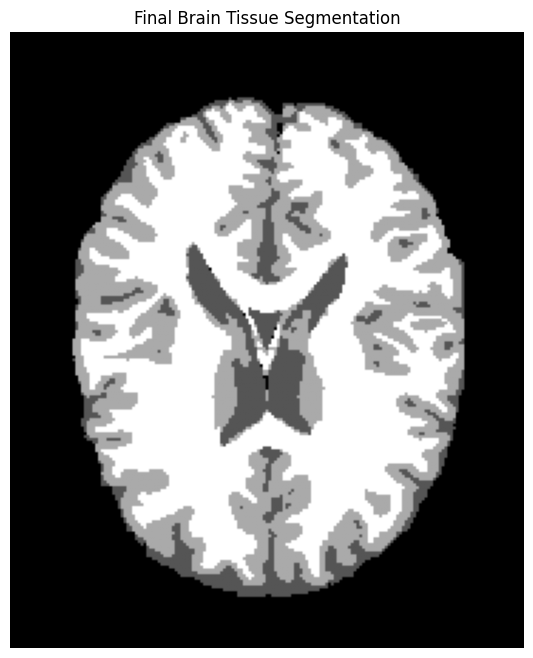


Intensity Mapping:

0   = Background
85  = CSF
170 = Gray Matter
255 = White Matter



In [12]:
# ============================================================
# SAVE SEGMENTATION FOR FIJI VISUALIZATION
# ============================================================

import numpy as np

# ============================================================
# CREATE VISUALIZATION VOLUME
# ============================================================

visual_volume = np.zeros(
    final_segmentation.shape,
    dtype=np.uint8
)

# ============================================================
# ASSIGN BRIGHTER INTENSITIES
# ============================================================

# ------------------------------------------------------------
# BACKGROUND = 0
# ------------------------------------------------------------

visual_volume[
    final_segmentation == 0
] = 0

# ------------------------------------------------------------
# CSF = 85
# ------------------------------------------------------------

visual_volume[
    final_segmentation == 1
] = 85

# ------------------------------------------------------------
# GRAY MATTER = 170
# ------------------------------------------------------------

visual_volume[
    final_segmentation == 2
] = 170

# ------------------------------------------------------------
# WHITE MATTER = 255
# ------------------------------------------------------------

visual_volume[
    final_segmentation == 3
] = 255

# ============================================================
# SAVE RAW FILE
# ============================================================

output_path = "segmentation_16x16.raw"

visual_volume.tofile(
    output_path
)

print("\nVisualization RAW Saved Successfully!")

print("Saved File =", output_path)

# ============================================================
# VERIFY SAVED FILE
# ============================================================

loaded_volume = np.fromfile(
    output_path,
    dtype=np.uint8
)

loaded_volume = loaded_volume.reshape(
    181,
    217,
    181
)

print("\nLoaded Shape =",
      loaded_volume.shape)

print("Unique Intensities =",
      np.unique(loaded_volume))

# ============================================================
# VISUALIZE ONE SLICE
# ============================================================

import matplotlib.pyplot as plt

slice_index = 90

plt.figure(figsize=(8,8))

plt.imshow(
    loaded_volume[slice_index],
    cmap='gray'
)

plt.title(
    "Final Brain Tissue Segmentation"
)

plt.axis("off")

plt.show()

# ============================================================
# FINAL INFORMATION
# ============================================================

print("""
Intensity Mapping:

0   = Background
85  = CSF
170 = Gray Matter
255 = White Matter
""")


Loading Final Segmentation...

Segmentation Shape = (181, 217, 181)

Unique Labels = [0 1 2 3]

Creating CSF Plot...

Creating Gray Matter Plot...

Creating White Matter Plot...


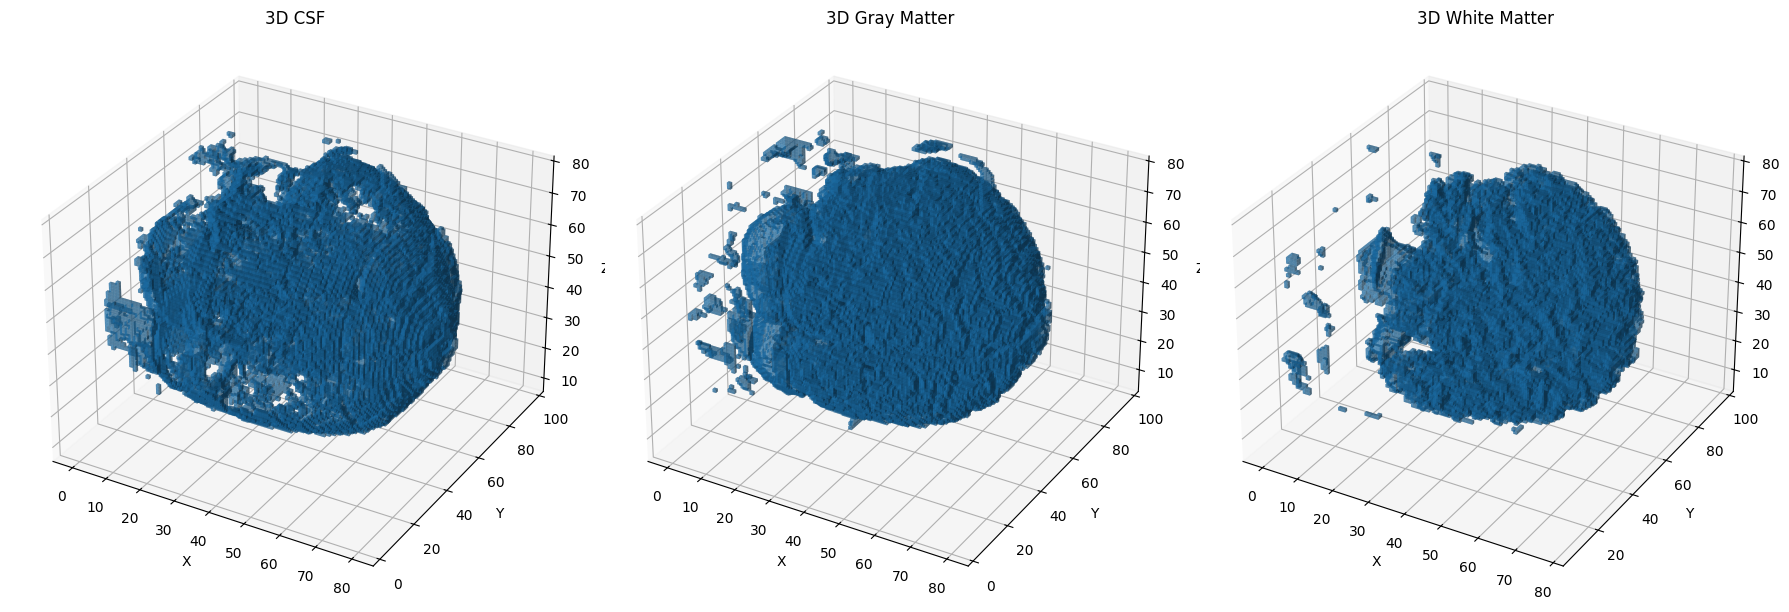


Separate 3D Tissue Visualization Completed!

Displayed Structures:

1. CSF Volume

2. Gray Matter Volume

3. White Matter Volume




RAW Files Saved Successfully!

Saved Files:

1. csf_segmentation16x16.raw
2. gm_segmentation16x16.raw
3. wm_segmentation16x16.raw


CSF Unique Values = [  0 255]
GM Unique Values = [  0 180]
WM Unique Values = [  0 255]


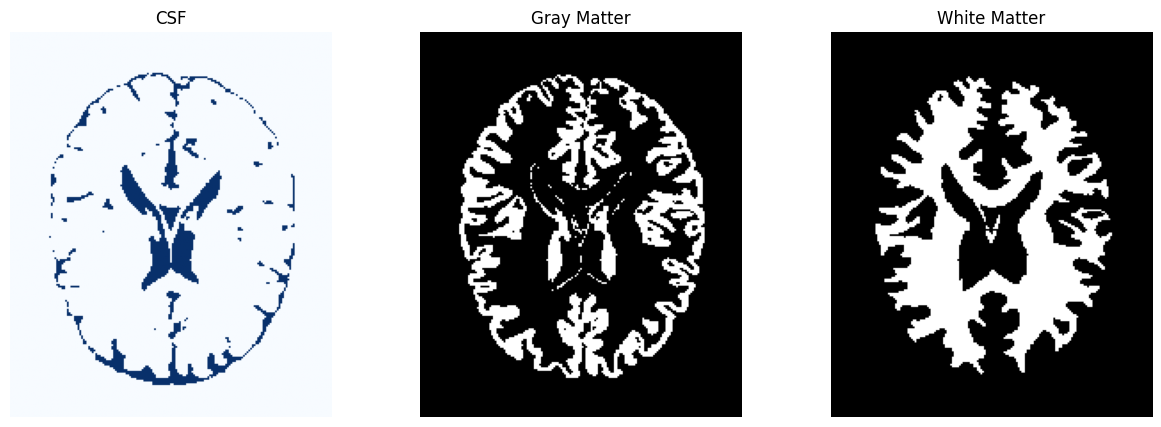


Segmentation Labels:

1 = CSF
2 = Gray Matter
3 = White Matter



In [13]:
# ============================================================
# SAVE CSF, GRAY MATTER, WHITE MATTER
# AS SEPARATE RAW FILES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CREATE EMPTY VOLUMES
# ============================================================

csf_volume = np.zeros(
    final_segmentation.shape,
    dtype=np.uint8
)

gm_volume = np.zeros(
    final_segmentation.shape,
    dtype=np.uint8
)

wm_volume = np.zeros(
    final_segmentation.shape,
    dtype=np.uint8
)

# ============================================================
# ASSIGN COLORS / INTENSITIES
# ============================================================

# ------------------------------------------------------------
# CSF → BRIGHT BLUE STYLE INTENSITY
# ------------------------------------------------------------

csf_volume[
    final_segmentation == 1
] = 255

# ------------------------------------------------------------
# GRAY MATTER → MEDIUM GRAY
# ------------------------------------------------------------

gm_volume[
    final_segmentation == 2
] = 180

# ------------------------------------------------------------
# WHITE MATTER → WHITE
# ------------------------------------------------------------

wm_volume[
    final_segmentation == 3
] = 255

# ============================================================
# SAVE RAW FILES
# ============================================================

csf_volume.tofile(
    "csf_segmentation16x16.raw"
)

gm_volume.tofile(
    "gm_segmentation16x16.raw"
)

wm_volume.tofile(
    "wm_segmentation16x16.raw"
)

print("\nRAW Files Saved Successfully!")

print("""
Saved Files:

1. csf_segmentation16x16.raw
2. gm_segmentation16x16.raw
3. wm_segmentation16x16.raw
""")

# ============================================================
# VERIFY FILES
# ============================================================

print("\nCSF Unique Values =",
      np.unique(csf_volume))

print("GM Unique Values =",
      np.unique(gm_volume))

print("WM Unique Values =",
      np.unique(wm_volume))

# ============================================================
# VISUALIZE SAMPLE SLICE
# ============================================================

slice_index = 90

plt.figure(figsize=(15,5))

# ------------------------------------------------------------
# CSF
# ------------------------------------------------------------

plt.subplot(1,3,1)

plt.imshow(
    csf_volume[slice_index],
    cmap='Blues'
)

plt.title("CSF")

plt.axis("off")

# ------------------------------------------------------------
# GRAY MATTER
# ------------------------------------------------------------

plt.subplot(1,3,2)

plt.imshow(
    gm_volume[slice_index],
    cmap='gray'
)

plt.title("Gray Matter")

plt.axis("off")

# ------------------------------------------------------------
# WHITE MATTER
# ------------------------------------------------------------

plt.subplot(1,3,3)

plt.imshow(
    wm_volume[slice_index],
    cmap='gray'
)

plt.title("White Matter")

plt.axis("off")

plt.show()

# ============================================================
# FINAL INFORMATION
# ============================================================

print("""
Segmentation Labels:

1 = CSF
2 = Gray Matter
3 = White Matter
""")